References:
- https://mingze-gao.com/posts/garch-estimation/ 
- https://onlinelibrary.wiley.com/doi/full/10.1002/jae.800


In [31]:
import yfinance as yf
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

symbol = 'AMZN'
start_date = '2021-01-01'
end_date = '2026-8-31'

stock = yf.Ticker(symbol)
historical_data = stock.history(start=start_date, end=end_date)
closing_price = historical_data["Close"]
print(closing_price)

Date
2021-01-04 00:00:00-05:00    159.331497
2021-01-05 00:00:00-05:00    160.925507
2021-01-06 00:00:00-05:00    156.919006
2021-01-07 00:00:00-05:00    158.108002
2021-01-08 00:00:00-05:00    159.134995
                                ...    
2026-08-24 00:00:00-04:00    262.070007
2026-08-25 00:00:00-04:00    261.059998
2026-08-26 00:00:00-04:00    260.279999
2026-08-27 00:00:00-04:00    256.260010
2026-08-28 00:00:00-04:00    266.429993
Name: Close, Length: 1420, dtype: float64


Date
2021-01-05 00:00:00-05:00    1.000436
2021-01-06 00:00:00-05:00   -2.489661
2021-01-07 00:00:00-05:00    0.757713
2021-01-08 00:00:00-05:00    0.649551
2021-01-11 00:00:00-05:00   -2.151946
                               ...   
2026-08-24 00:00:00-04:00    1.330086
2026-08-25 00:00:00-04:00   -0.385397
2026-08-26 00:00:00-04:00   -0.298781
2026-08-27 00:00:00-04:00   -1.544486
2026-08-28 00:00:00-04:00    3.968619
Name: Close, Length: 1419, dtype: float64


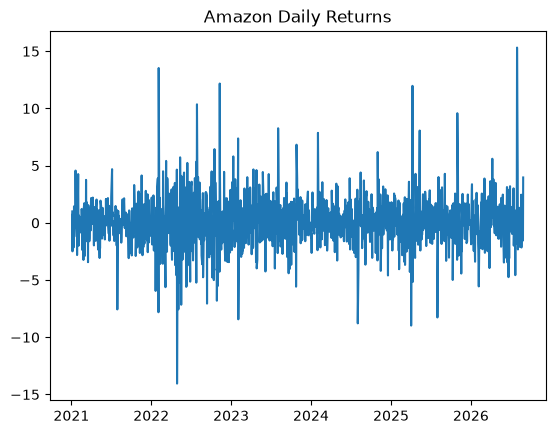

In [32]:
# daily_returns = []
# for i in range(1, len(closing_price)):
#     prev, today = closing_price.iloc[i - 1], closing_price.iloc[i]
#     daily_returns.append(float((today - prev) / prev) * 100)
# The pandas version of this:
daily_returns = closing_price.pct_change().dropna() * 100
print(daily_returns)

plt.plot(daily_returns)
plt.title("Amazon Daily Returns")
plt.show()

## Research / Understanding

Typically, we might model returns as $r_t = \mu + \epsilon_t$, where $\epsilon_t$ is like the "unpredictable shock" at time t (error term). With normal regression, we typically assume that the $\epsilon_t$ term has a normal distribution where the variance is a constant (i.e. $\epsilon_t \sim N(0, \sigma^2)$)

However, in many real life scenarios and especially in finance, this is not true - variance almost certainly varies. For example, if some world
event causes the market to crash, your returns will likely be drastically different than before this event. While the average/mean may stay
the same, the variance will likely explode!

Moreover, after these events, values tend to move _together_. That is, large errors tend to be followed by large errors; shocks can create elevated periods of uncertainty instead of only affecting ONE time instant. For example, if something happens at $t - 1$, it is very likely that time $t$ will be digesting it.

This is where ARCH (Autoregressive Conditional Heteroskedasticity) comes in. Instead of modelling variance as a constant term, it becomes a function of the past residuals, also called the __conditional variance__:

$$
\text{ARCH}(p): \sigma_t^2 = \alpha_0 + \sum_{i=1}^{p} \alpha_i \epsilon_{t-i}^2
$$

where $p$ is the number of time periods to take into consideration (also called the _lag_ parameter). For example, if $p=1$, we would get:

$$
\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2
$$

As one may expect, ARCH typically assumes that the mean process has already been made stationary, so changes in the residuals can be interpreted as changes in volatility rather than changes in the mean. 

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) is an extension of ARCH that incorporates a moving average component. More specifically, this model includes __lag variance__ terms in addition to the lag residuals to more accurately capture __volitility persistence__. The formula for the variance calulcated this way is:

$$
\text{GARCH}(p, q): \sigma_t^2 = \omega + \sum_{i=1}^{p}\alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{q}\beta_j \sigma_{t-j}^2
$$

where $p$ is the number of lagged square residuals and $q$ is the number of lagged variances. For example, with $p=1$ and $q=1$:

$$ \sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2 $$

Just like with ARCH, GARCH assumes the mean process is stationary.

With this new definition of the variance, we arrive at the _shock equation_ to come up with the $\epsilon$ (often called _shock_ or _innovation_ ) term:

$$
\epsilon_t = \sigma_t \times z_t
$$

where $z_t \sim N(0,1)$ is the white noise / error term.

In [33]:
# Test to see if this data has a constant mean using the ADF test.
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_returns)
print("ADF statistic:", result[0])
print(f"p-value: {result[1]:.20e}")
print("Critical values:", result[4])

ADF statistic: -37.17855887646782
p-value: 0.00000000000000000000e+00
Critical values: {'1%': np.float64(-3.4349700122033804), '5%': np.float64(-2.8635804131233096), '10%': np.float64(-2.567856305330816)}


/var/folders/lr/j24s_bfs3gq2mpzj68hxqz2m0000gn/T/ipykernel_82657/1083228451.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(daily_returns)


With a p-value that small, there is very strong evidence against the null hypothesis ($H_0$: we have a non-constant mean). Thus, we will reject it and conclude that the series is stationary. GARCH applies!

The next thing we look for is autocorrelation, which simply refers to how correlated a series is with a _delayed/lagged version of itself_. An Autocorrelation Function (ACF) plot helps us visualize this information. 

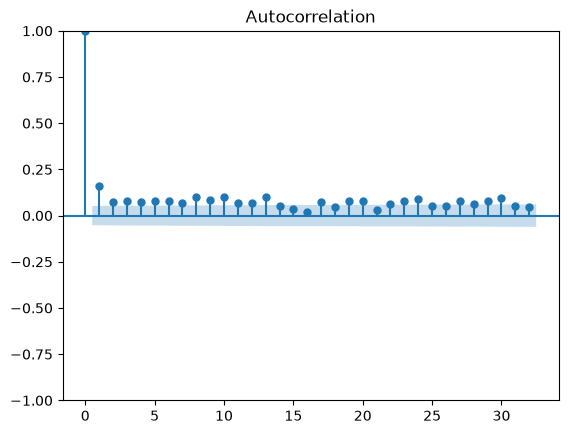

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

abs_daily_returns = abs(daily_returns)
plot_acf(abs_daily_returns)
plt.show()

Note the blue band in the graph - this is a confidence band for the autocorrelation under the null hypothesis (that the true autocorrelation is 0).

From this, we can see that many of the points are positively correlated and outside the blue confidence band ("this correlation is large enough that it would be unlikely to arise purely by chance if the true correlation at that lag were zero"). 

We can conclude that the magnitude of the residuals is positively autocorrelated over time, or that there is volatility clustering/persistence!

With this, we can pretty confidently proceed with creating an ARCH/GARCH model!

Available forecasts: 284


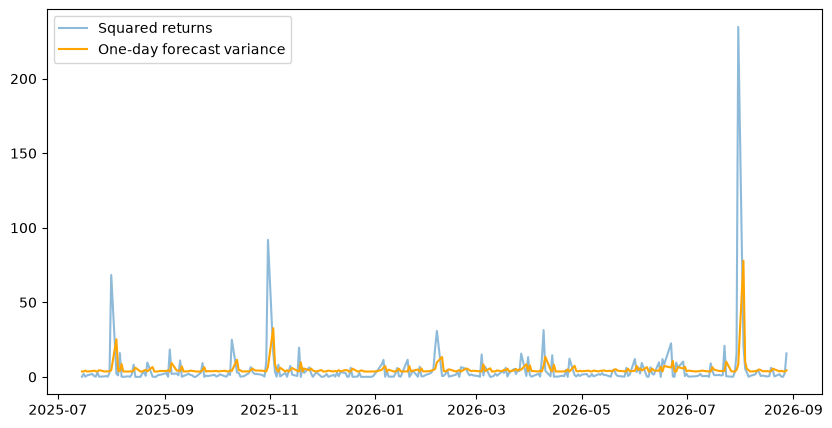

In [35]:
from arch import arch_model

# Create train and test split, 80% to 20% respectively.
index = int(len(daily_returns) * 0.8)
train, test = daily_returns.iloc[:index], daily_returns[index:]
p, q = 1, 1

# ARCH model.
arch = arch_model(
    daily_returns,
    mean="Zero",
    vol="ARCH",
    p=p
)

model = arch.fit(last_obs=index, disp="off")

forecast = model.forecast(
    start=index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

print("Available forecasts:", forecast_variance.notna().sum())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test**2, label="Squared returns", alpha=0.5)
plt.plot(
    test.index,
    forecast_variance,
    label="One-day forecast variance",
    color="orange"
)
plt.legend()
plt.show()

Available forecasts: 284


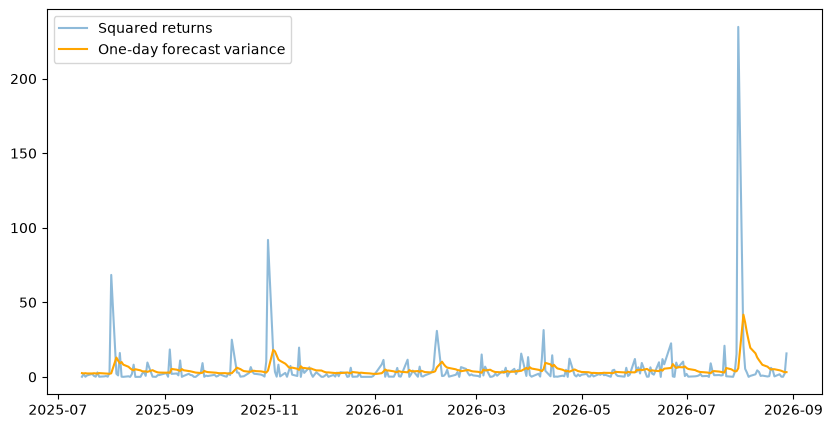

In [36]:
# GARCH.
garch = arch_model(
    daily_returns,
    mean="Zero",
    vol="GARCH",
    p=p,
    q=q
)

model = garch.fit(last_obs=index, disp="off")

forecast = model.forecast(
    start=index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

print("Available forecasts:", forecast_variance.notna().sum())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test**2, label="Squared returns", alpha=0.5)
plt.plot(
    test.index,
    forecast_variance,
    label="One-day forecast variance",
    color="orange"
)
plt.legend()
plt.show()


Okay time to improve on the $p$ and $q$ values, or possibly even prove that $p=1$ and $q=1$ are optimal.

There does not seem to be an easy, out-of-the-box `GridSearchCV` function to use, so we must manually test these parameters ourselves.

Actually, doing some more research, it seems like the GARCH(1,1) is a __very__ strong baseline. There is a paper by Hansen and Lunde on this. However, they conclude that GARCH(1,1) is not universally the best. Thus, it might be worthwhile to do some own digging to see if they are the best for our case! My hunch is that it will be, but there is really no harm in learning more and trying more things!

Seems like using AIC and BIC to check the parameters is a good first step.

In [37]:
bestAic, bestBic = float("inf"), float("inf")
bestAicPair, bestBicPair = None, None

# Test all p, q combinations for 1 <= p, q <= 5.
for p in range(1, 6):
    for q in range(1, 6):
        garch = arch_model(
            daily_returns,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q
        )
        model = garch.fit(last_obs=index, disp="off")

        aic, bic = model.aic, model.bic
        if aic < bestAic:
            bestAicPair = (p, q)
            bestAic = aic
        if bic < bestBic:
            bestBicPair = (p, q)
            bestBic = bic

print("Best AIC:", bestAic, bestAicPair)
print("Best BIC:", bestBic, bestBicPair)
        

Best AIC: 4907.655139658595 (1, 3)
Best BIC: 4922.958858472188 (1, 1)


Seems like BIC, which penalizes complex models more heavily to avoid overfitting, prefers the GARCH(1,1) model. AIC, which is less punishing on complex models, prefers a GARCH(1, 3). Since this is related to volatile trading data, overfitting seems more dangerous - I would go with the BIC, which means we don't have to change our GARCH model!

Now, this AIC and BIC check is concerned only with maximizing the MLE based on the training set's data, not the actual forecasted values. I think it would also be worthwhile to check how accurate the forecasted values are (i.e. the test set).

In [38]:
# We check forecasting results on the test set. 

import numpy as np

results = []

for p in range(1, 6):
    for q in range(1, 6):
        garch = arch_model(
            daily_returns,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q
        )

        model = garch.fit(last_obs=index, disp="off")

        forecast = model.forecast(
            start=index - 1,
            horizon=1,
            align="target",
            reindex=True
        )

        forecast_variance = forecast.variance["h.1"].loc[test.index]

        # Log likelihood of each actual return under N(0, predicted_variance)
        # i.e. "how likely was this return, supposing it was distributed WRT the predicted variance?"
        log_likelihoods = -0.5 * (
            np.log(2 * np.pi)
            + np.log(forecast_variance)
            + (test ** 2) / forecast_variance
        )

        results.append({
            "p": p,
            "q": q,
            "log_likelihood": log_likelihoods.sum(),
            "avg_log_likelihood": log_likelihoods.mean()
        })

results = pd.DataFrame(results)

print(
    results.sort_values(
        "avg_log_likelihood",
        ascending=False
    )
)

    p  q  log_likelihood  avg_log_likelihood
11  3  2     -623.093663           -2.193992
1   1  2     -623.095853           -2.193999
6   2  2     -623.096292           -2.194001
21  5  2     -623.096560           -2.194002
16  4  2     -623.097015           -2.194004
2   1  3     -623.227241           -2.194462
4   1  5     -623.227481           -2.194463
3   1  4     -623.228319           -2.194466
20  5  1     -625.267354           -2.201646
10  3  1     -625.267401           -2.201646
5   2  1     -625.268017           -2.201648
0   1  1     -625.268022           -2.201648
15  4  1     -625.268490           -2.201650
13  3  4     -627.655892           -2.210056
23  5  4     -627.658192           -2.210064
18  4  4     -627.658289           -2.210064
24  5  5     -627.687264           -2.210166
19  4  5     -627.687359           -2.210167
14  3  5     -627.687418           -2.210167
12  3  3     -627.765851           -2.210443
22  5  3     -627.766634           -2.210446
17  4  3  

As the comment mentioned, the log likelihood calculation is essentially calculating the probability of observing that specific return value under the predicted variance. Since the natural logarithm function is increasing, a higher probability corresponds to a greater log likelihood value. 

(Yes, we are using the probability __density__ function, which means $f(x)$ is NOT a probability, but we can assume it is for a very small interval \[$x, \Delta x$\])

Interestingly enough, our results show that $p=3$ and $q=2$ leads to the best forecasting results! 

However, looking more closely at the data, we see an interesting trend with the top 5 results; they all have $q=2$. Moreover, the differences between these top 5 log likelihood results are all very small. This makes $p=1$ and $q=2$ a potential candidate.

Okay before we proceed, I'm going to split the data into 3 sets - train, validation, and test. This allows us to evaluate our $p$ and $q$ discoveries better.

    p  q  avg_log_likelihood
15  4  1           -2.117938
10  3  1           -2.117938
20  5  1           -2.117939
5   2  1           -2.117939
0   1  1           -2.117939
1   1  2           -2.127257
2   1  3           -2.127258
12  3  3           -2.128875
11  3  2           -2.128875
16  4  2           -2.128875
7   2  3           -2.128875
22  5  3           -2.128875
6   2  2           -2.128876
21  5  2           -2.128876
17  4  3           -2.128877
14  3  5           -2.133990
13  3  4           -2.133992
24  5  5           -2.133994
23  5  4           -2.133995
19  4  5           -2.133995
9   2  5           -2.133997
8   2  4           -2.133997
18  4  4           -2.134000
4   1  5           -2.179089
3   1  4           -2.184080
Best validation model: GARCH(4, 1)
Final test average log likelihood: -2.201649611577286


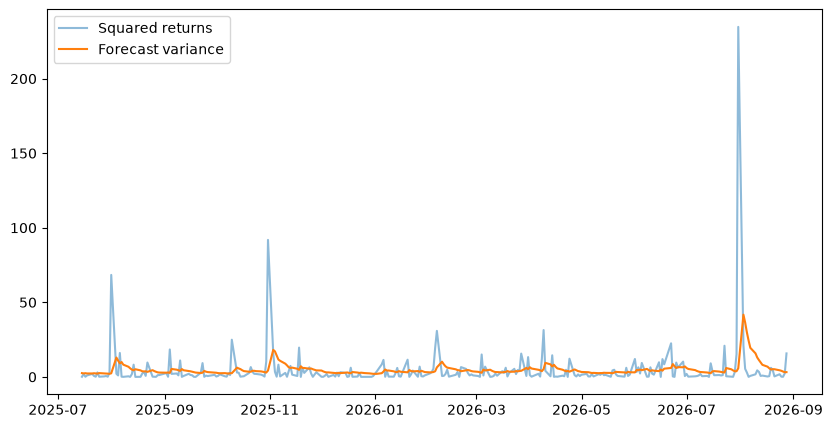

In [39]:
# Split the data into train (60%), validation (20%), and test (20%).
train_index = int(len(daily_returns) * 0.6)
validation_index = int(len(daily_returns) * 0.8)

train = daily_returns.iloc[:train_index]
validation = daily_returns.iloc[train_index:validation_index]
test = daily_returns.iloc[validation_index:]

# First, use the validation set to find the best p and q values.
results = []

for p in range(1, 6):
    for q in range(1, 6):
        garch = arch_model(
            daily_returns,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q
        )

        # Only the training set is used to find the model parameters.
        model = garch.fit(last_obs=train_index, disp="off")

        forecast = model.forecast(
            start=train_index - 1,
            horizon=1,
            align="target",
            reindex=True
        )

        forecast_variance = forecast.variance["h.1"].loc[validation.index]

        # Check the one-day forecasts on the validation set.
        log_likelihoods = -0.5 * (
            np.log(2 * np.pi)
            + np.log(forecast_variance)
            + (validation ** 2) / forecast_variance
        )

        results.append({
            "p": p,
            "q": q,
            "avg_log_likelihood": log_likelihoods.mean()
        })

results = pd.DataFrame(results).sort_values(
    "avg_log_likelihood",
    ascending=False
)
print(results)

# The p and q with the highest validation log likelihood win.
best_p = int(results.iloc[0]["p"])
best_q = int(results.iloc[0]["q"])
print(f"Best validation model: GARCH({best_p}, {best_q})")

# Now refit the winner using both the train and validation sets.
garch = arch_model(
    daily_returns,
    mean="Zero",
    vol="GARCH",
    p=best_p,
    q=best_q
)
model = garch.fit(last_obs=validation_index, disp="off")

forecast = model.forecast(
    start=validation_index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

# Finally, check the chosen model once on the untouched test set.
test_log_likelihoods = -0.5 * (
    np.log(2 * np.pi)
    + np.log(forecast_variance)
    + (test ** 2) / forecast_variance
)

print("Final test average log likelihood:", test_log_likelihoods.mean())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test ** 2, label="Squared returns", alpha=0.5)
plt.plot(test.index, forecast_variance, label="Forecast variance")
plt.legend()
plt.show()


Some even more interesting results. With this latest split, we get that the top 5 results all have $q=1$, with small differences in the log likelihood between them. This is actually more proof that the baseline GARCH(1,1) is quite appropriate for our dataset. 

The previous difference with an emphasis on the performance of $q=2$ seems to reflect sensitivty to the way the dataset was split. I think it would be reasonable to test multiple different splits to try and "average out the sensitivity". 

After some research, it seems like using a time series cross-validation would work well, as noted in the online textbook _Forecasting: Principles and Practice_.

    p  q  avg_log_likelihood  std_log_likelihood  converged
5   2  1           -2.080808            0.118869       True
0   1  1           -2.080811            0.118867       True
10  3  1           -2.080811            0.118868       True
15  4  1           -2.080813            0.118869       True
20  5  1           -2.082452            0.121352       True
1   1  2           -2.089649            0.118341       True
17  4  3           -2.090459            0.118424       True
22  5  3           -2.090459            0.118424       True
12  3  3           -2.090460            0.118424       True
7   2  3           -2.090460            0.118423       True
14  3  5           -2.091169            0.128356       True
2   1  3           -2.091521            0.117153       True
6   2  2           -2.091919            0.123126       True
11  3  2           -2.091921            0.123129       True
21  5  2           -2.092243            0.123395       True
16  4  2           -2.092244            

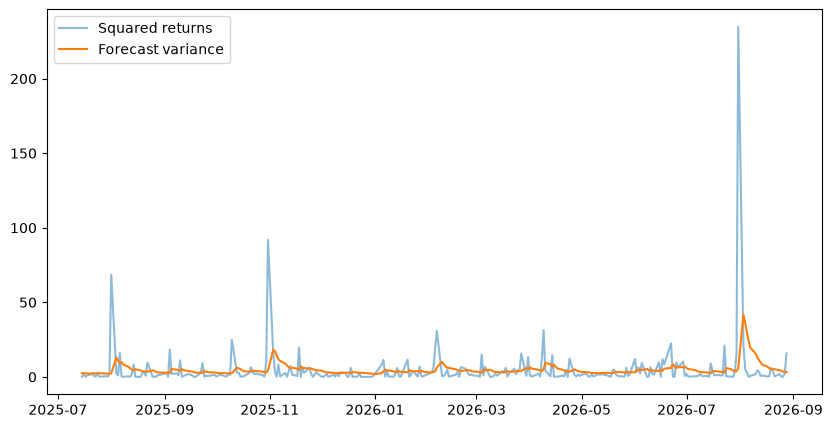

In [40]:
# Keep the final 20% of the data untouched for our final test.
test_index = int(len(daily_returns) * 0.8)
development = daily_returns.iloc[:test_index]
test = daily_returns.iloc[test_index:]

# Create 5 expanding-window folds within the development data.
number_of_folds = 5
validation_size = len(development) // 10
first_train_size = len(development) - number_of_folds * validation_size

results = []

# Once again, test all p and q combinations from 1 to 5.
for p in range(1, 6):
    for q in range(1, 6):
        fold_scores = []
        all_converged = True

        for fold in range(number_of_folds):
            train_end = first_train_size + fold * validation_size
            validation_end = train_end + validation_size

            # The training set expands for every fold.
            fold_data = development.iloc[:validation_end]
            fold_validation = development.iloc[train_end:validation_end]

            garch = arch_model(
                fold_data,
                mean="Zero",
                vol="GARCH",
                p=p,
                q=q
            )

            # Only the training portion of this fold is used to fit the model.
            model = garch.fit(last_obs=train_end, disp="off")

            if model.convergence_flag != 0:
                all_converged = False

            forecast = model.forecast(
                start=train_end - 1,
                horizon=1,
                align="target",
                reindex=True
            )

            forecast_variance = (
                forecast.variance["h.1"]
                .loc[fold_validation.index]
            )

            log_likelihoods = -0.5 * (
                np.log(2 * np.pi)
                + np.log(forecast_variance)
                + (fold_validation ** 2) / forecast_variance
            )

            fold_scores.append(log_likelihoods.mean())

        results.append({
            "p": p,
            "q": q,
            "avg_log_likelihood": np.mean(fold_scores),
            "std_log_likelihood": np.std(fold_scores),
            "converged": all_converged
        })

results = pd.DataFrame(results).sort_values(
    "avg_log_likelihood",
    ascending=False
)
print(results)

# Choose the converged model with the highest average validation score.
converged_results = results[results["converged"]]
best_p = int(converged_results.iloc[0]["p"])
best_q = int(converged_results.iloc[0]["q"])
print(f"Best cross-validation model: GARCH({best_p}, {best_q})")

# Refit the winner on all of the development data.
garch = arch_model(
    daily_returns,
    mean="Zero",
    vol="GARCH",
    p=best_p,
    q=best_q
)
model = garch.fit(last_obs=test_index, disp="off")

forecast = model.forecast(
    start=test_index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

# Finally, check the chosen model once on the untouched test set.
test_log_likelihoods = -0.5 * (
    np.log(2 * np.pi)
    + np.log(forecast_variance)
    + (test ** 2) / forecast_variance
)

print("Final test average log likelihood:", test_log_likelihoods.mean())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test ** 2, label="Squared returns", alpha=0.5)
plt.plot(test.index, forecast_variance, label="Forecast variance")
plt.legend()
plt.show()


While GARCH(1,1) is not first in that list, the difference is marginal. This entire experiment has convinced me that GARCH(1,1) would work well with our data! Using less parameters, we become less prone to overfitting, so I am much more confident choosing GARCH(1,1) as opposed to more parameters and a hardly noticeable improvement. This is probably even more true for the world of finance (believe the term is __parsimony__).